In [1]:
from os import listdir
from os.path import isfile, join
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from timeit import default_timer as timer
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Activation, MaxPooling1D, Dropout
from tensorflow.keras.utils import plot_model,to_categorical

In [42]:
from sklearn.preprocessing import LabelEncoder

In [2]:
class Diagnosis():
    def __init__ (self, id, diagnosis, image_path):
        self.id = id
        self.diagnosis = diagnosis 
        self.image_path = image_path   

In [24]:
def get_wav_files():
    audio_path = 'Respiratory_Sound_Database/audio_and_txt_files/'
    files = [f for f in listdir(audio_path) if isfile(join(audio_path, f))]  #Gets all files in dir
    wav_files = [f for f in files if f.endswith('.wav')]  # Gets wav files 
    wav_files = sorted(wav_files)
    return wav_files, audio_path

In [25]:
def diagnosis_data():
    diagnosis = pd.read_csv('Respiratory_Sound_Database/patient_diagnosis.csv')
  
    wav_files, audio_path = get_wav_files()
    diag_dict = { 101 : "URTI"}  
    diagnosis_list = []
  
    for index , row in diagnosis.iterrows():
        diag_dict[row[0]] = row[1]     

    c = 0
    for f in wav_files:
        diagnosis_list.append(Diagnosis(c, diag_dict[int(f[:3])], audio_path+f))  
    c+=1  

    return diagnosis_list

In [26]:
def audio_features(filename): 
    sound, sample_rate = librosa.load(filename)
    stft = np.abs(librosa.stft(sound))  
 
    mfccs = np.mean(librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40),axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate),axis=1)
    mel = np.mean(librosa.feature.melspectrogram(sound, sr=sample_rate),axis=1)
    contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate),axis=1)
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound), sr=sample_rate),axis=1)
    
    concat = np.concatenate((mfccs,chroma,mel,contrast,tonnetz))
    return concat

def data_points():
    labels = []
    images = []
    to_hot_one = {"COPD":0, "Healthy":1, "URTI":2, "Bronchiectasis":3, "Pneumonia":4, "Bronchiolitis":5, "Asthma":6, "LRTI":7}
    count = 0
    for f in diagnosis_data():
        print(count)
        labels.append(to_hot_one[f.diagnosis]) 
        images.append(audio_features(f.image_path))
        count+=1

    return np.array(labels), np.array(images)

In [27]:
def preprocessing(labels, images):    
    # Remove Asthma and LRTI
    images = np.delete(images, np.where((labels == 7) | (labels == 6))[0], axis=0) 
    labels = np.delete(labels, np.where((labels == 7) | (labels == 6))[0], axis=0)      

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=10)

    # Hot one encode the labels
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)  

    # Format new data
    y_train = np.reshape(y_train, (y_train.shape[0], 6))
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    y_test = np.reshape(y_test, (y_test.shape[0], 6))
    X_test = np.reshape(X_test, (X_test.shape[0], X_train.shape[1],  1))

    return X_train, X_test, y_train, y_test

In [82]:
X_test.shape

(184, 193, 1)

In [28]:
start = timer()

labels, images = data_points()
X_train, X_test, y_train, y_test = preprocessing(labels, images)

print('Time taken: ', (timer() - start))

0
1
2
3


c:\users\dell\appdata\local\programs\python\python36\lib\site-packages\librosa\core\pitch.py:153: UserWarning: Trying to estimate tuning from empty frequency set.
  warnings.warn("Trying to estimate tuning from empty frequency set.")


4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
27

In [38]:
images.size

177560

In [39]:
images=np.array(images)

In [70]:
unique_elements, counts_elements = np.unique(labels, return_counts=True)
print(np.asarray((unique_elements, counts_elements)))

[[  0   1   2   3   4   5]
 [793  35  23  16  37  13]]


In [69]:
images = np.delete(images, np.where((labels == 7) | (labels == 6))[0], axis=0) 
labels = np.delete(labels, np.where((labels == 7) | (labels == 6))[0], axis=0)

In [45]:
le = LabelEncoder()
i_labels = le.fit_transform(labels)
oh_labels = to_categorical(i_labels) 
oh_labels

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

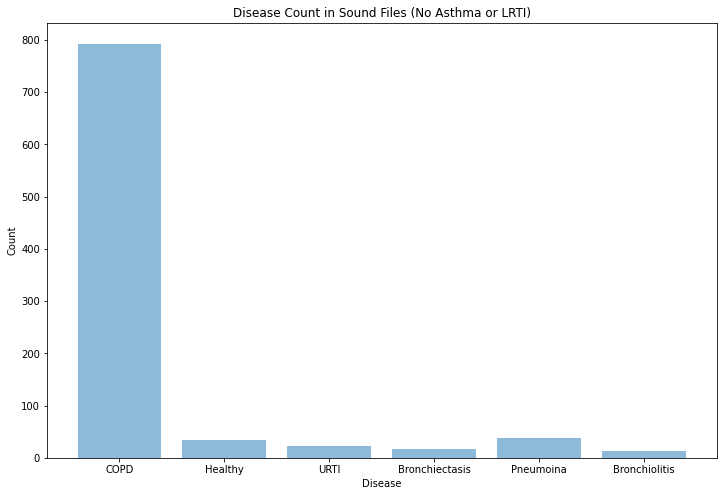

In [78]:
y_pos = np.arange(len(unique_elements))
plt.figure(figsize=(12,8))
plt.bar(unique_elements, counts_elements, align='center', alpha=0.5)
plt.xticks(y_pos, c_names)
plt.ylabel('Count')
plt.xlabel('Disease')
plt.title('Disease Count in Sound Files (No Asthma or LRTI)')
plt.show()

In [29]:
model = Sequential()
model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(193, 1)))

model.add(Conv1D(128, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(2)) 

model.add(Conv1D(256, kernel_size=5, activation='relu'))

model.add(Dropout(0.3))
model.add(Flatten())

model.add(Dense(512, activation='relu'))   
model.add(Dense(6, activation='softmax'))

In [30]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=70, batch_size=200, verbose=1)

Epoch 1/70
4/4 [==============================] - 4s 430ms/step - loss: 3.2187 - accuracy: 0.8213 - val_loss: 13.7718 - val_accuracy: 0.0543
Epoch 2/70
4/4 [==============================] - 1s 294ms/step - loss: 3.6487 - accuracy: 0.5975 - val_loss: 0.5382 - val_accuracy: 0.8967
Epoch 3/70
4/4 [==============================] - 1s 306ms/step - loss: 0.8645 - accuracy: 0.8568 - val_loss: 0.4639 - val_accuracy: 0.8967
Epoch 4/70
4/4 [==============================] - 1s 296ms/step - loss: 0.6373 - accuracy: 0.8568 - val_loss: 0.4620 - val_accuracy: 0.8859
Epoch 5/70
4/4 [==============================] - 1s 304ms/step - loss: 0.5503 - accuracy: 0.8431 - val_loss: 0.3803 - val_accuracy: 0.8967
Epoch 6/70
4/4 [==============================] - 1s 303ms/step - loss: 0.4987 - accuracy: 0.8568 - val_loss: 0.3911 - val_accuracy: 0.8967
Epoch 7/70
4/4 [==============================] - 1s 307ms/step - loss: 0.4743 - accuracy: 0.8568 - val_loss: 0.3451 - val_accuracy: 0.8967
Epoch 8/70
4/4 [===

4/4 [==============================] - 2s 386ms/step - loss: 0.0587 - accuracy: 0.9768 - val_loss: 0.1657 - val_accuracy: 0.9511
Epoch 60/70
4/4 [==============================] - 2s 412ms/step - loss: 0.0453 - accuracy: 0.9877 - val_loss: 0.1666 - val_accuracy: 0.9402
Epoch 61/70
4/4 [==============================] - 2s 385ms/step - loss: 0.0381 - accuracy: 0.9918 - val_loss: 0.2014 - val_accuracy: 0.9348
Epoch 62/70
4/4 [==============================] - 2s 376ms/step - loss: 0.0453 - accuracy: 0.9836 - val_loss: 0.1952 - val_accuracy: 0.9402
Epoch 63/70
4/4 [==============================] - 2s 415ms/step - loss: 0.0356 - accuracy: 0.9905 - val_loss: 0.1945 - val_accuracy: 0.9239
Epoch 64/70
4/4 [==============================] - 2s 386ms/step - loss: 0.0501 - accuracy: 0.9768 - val_loss: 0.1861 - val_accuracy: 0.9457
Epoch 65/70
4/4 [==============================] - 2s 383ms/step - loss: 0.0521 - accuracy: 0.9823 - val_loss: 0.2188 - val_accuracy: 0.9402
Epoch 66/70
4/4 [========

In [31]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 189, 64)           384       
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 185, 128)          41088     
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 92, 128)           0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 88, 256)           164096    
_________________________________________________________________
dropout (Dropout)            (None, 88, 256)           0         
_________________________________________________________________
flatten (Flatten)            (None, 22528)             0         
_________________________________________________________________
dense (Dense)                (None, 512)               1

In [47]:
score = model.evaluate(X_train, y_train, verbose=0)
print("Training Accuracy: ", score[1])

score = model.evaluate(X_test, y_test, verbose=0)
print("Testing Accuracy: ", score[1])

Training Accuracy:  0.9972714781761169
Testing Accuracy:  0.945652186870575


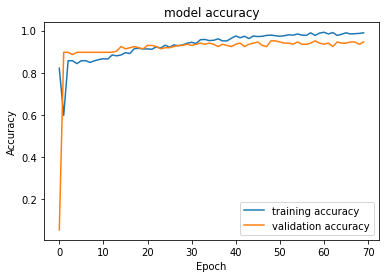

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['training accuracy','validation accuracy'],loc='lower right')
plt.show()

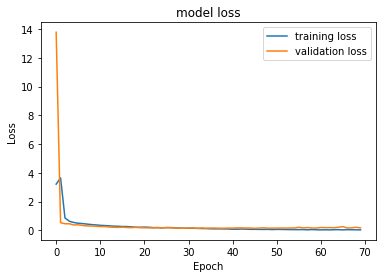

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['training loss','validation loss'],loc='upper right')
plt.show()

In [68]:
matrix_index = ["COPD", "Healthy", "URTI", "Bronchiectasis", "Pneumoina", "Bronchiolitis"]

preds = model.predict(X_test)
classpreds = np.argmax(preds, axis=1) # predicted classes 
y_testclass = np.argmax(y_test, axis=1) # true classes

print(classification_report(y_testclass, classpreds, target_names=matrix_index))

                precision    recall  f1-score   support

          COPD       0.98      0.99      0.98       165
       Healthy       0.67      0.57      0.62         7
          URTI       0.67      0.50      0.57         4
Bronchiectasis       1.00      0.50      0.67         4
     Pneumoina       0.60      1.00      0.75         3
 Bronchiolitis       0.00      0.00      0.00         1

      accuracy                           0.95       184
     macro avg       0.65      0.59      0.60       184
  weighted avg       0.95      0.95      0.95       184



In [63]:
c_names = ["COPD", "Healthy", "URTI", "Bronchiectasis", "Pneumoina", "Bronchiolitis"]
cf_matrix=confusion_matrix(y_testclass, classpreds)
cf_matrix

array([[163,   0,   0,   0,   2,   0],
       [  1,   4,   1,   0,   0,   1],
       [  0,   1,   2,   0,   0,   1],
       [  2,   0,   0,   2,   0,   0],
       [  0,   0,   0,   0,   3,   0],
       [  0,   1,   0,   0,   0,   0]], dtype=int64)

In [64]:
import itertools
def plot_confusion_matrix(cf_matrix,classes,normalize=False,title='Confusion Matrix',cmap=plt.cm.Blues):
    plt.imshow(cf_matrix,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=90)
    plt.yticks(tick_marks,classes)
    print(cf_matrix)
    thresh=cf_matrix.max()/2
    for i,j in itertools.product(range(cf_matrix.shape[0]),range(cf_matrix.shape[1])):
        plt.text(j,i,cf_matrix[i,j],horizontalalignment="center",color="white" if cf_matrix[i,j]>thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

[[163   0   0   0   2   0]
 [  1   4   1   0   0   1]
 [  0   1   2   0   0   1]
 [  2   0   0   2   0   0]
 [  0   0   0   0   3   0]
 [  0   1   0   0   0   0]]


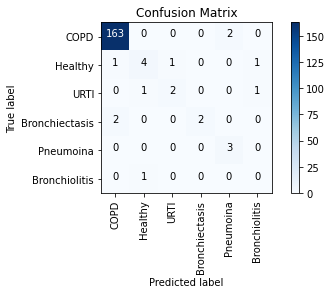

In [65]:
plot_confusion_matrix(cf_matrix,c_names,title='Confusion Matrix')

In [92]:
import IPython.display as ipd
fname='Respiratory_Sound_Database/audio_and_txt_files/102_1b1_Ar_sc_Meditron.wav'
feas=audio_features(fname)
feas=feas.reshape(1,193,1)
pred=model.predict(feas)
preds=np.argmax(pred,axis=1)
pred_class=c_names[preds[0]]
print(pred_class)
ipd.Audio(fname)

Healthy


In [93]:
print(preds)

[1]
